# Hypothesis Testing

### Import Libraries

In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path so `import src` works when notebook is run from `notebooks/`
proj_root = Path.cwd().resolve().parent
proj_root_str = str(proj_root)
if proj_root_str not in sys.path:
    sys.path.insert(0, proj_root_str)
print('Added to sys.path:', proj_root_str)

Added to sys.path: C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics


In [2]:
from src.data_loader import (
    load_cleaned_data,
)

from src.hypothesis_tests import (
    plot_statistical_distribution,
    plot_poisson_distribution
)

#### Load data

In [3]:
df = load_cleaned_data(file_path="../data/processed/insurance_data.csv")
df.head()

INFO:src.data_loader:Loading cleaned data from: ../data/processed/insurance_data.csv
C:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\src\data_loader.py:88: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates=parse_dates)
INFO:src.data_loader:✅ Cleaned data loaded successfully! Shape: (989483, 47)
INFO:src.data_loader:Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSe

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,LegalType,Title,Language,Bank,AccountType,MaritalStatus,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Margin,LossRatio
0,145249,12827,2015-03-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
1,145249,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,21.929825,0.0
2,145249,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0
3,145255,12827,2015-05-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,512.848070,0.0
4,145255,12827,2015-07-01,True,Close Corporation,Mr,English,First National Bank,Current account,Not specified,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.000000,0.0


## statistical distribution

In [4]:
severity_df = df[df['TotalClaims'] > 0] # Focus on claim severity (non-zero claims)

#### Claim Frequency

In [5]:
# policies and claims
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

In [6]:
print(df['HasClaim'].value_counts())
print(f"Total Claims found: {df['HasClaim'].sum()}")

HasClaim
0    986723
1      2760
Name: count, dtype: int64
Total Claims found: 2760


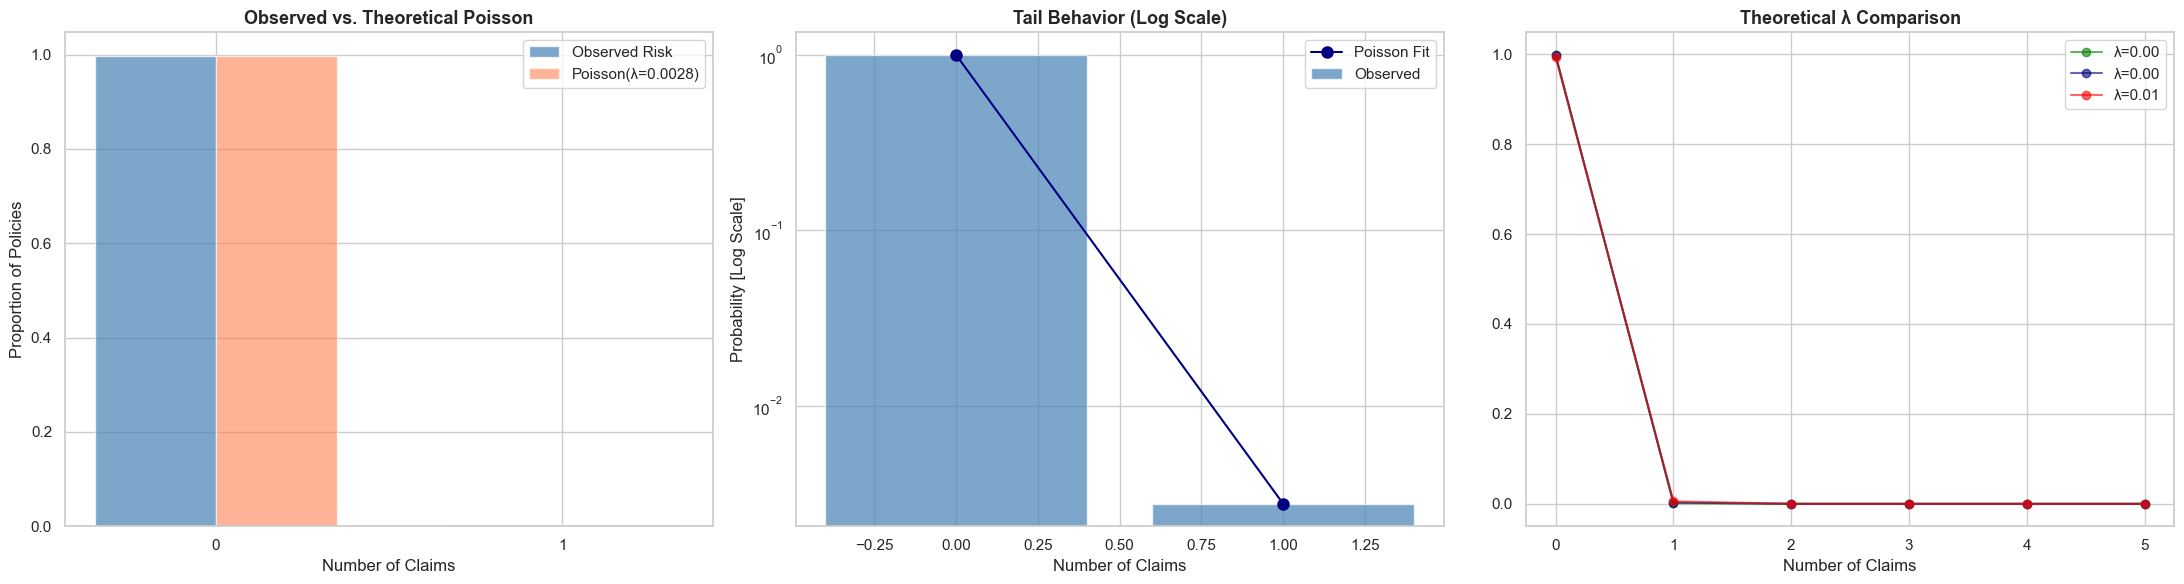

=== Poisson Analysis Summary for HasClaim ===
Overall λ (Claim Frequency): 0.00279
Overall Variance:           0.00278
Ratio (Var/Mean):           0.997 (Ideally ≈ 1 for Poisson)

Business Insight: Higher λ indicates a segment with higher service costs and risk frequency (Slide 8).


In [8]:
plot_poisson_distribution(df, column='HasClaim', title_suffix="- Claim Frequency Analysis (Poisson Distribution Fit)")

**Observation:** It means on average, for every 1,000 policies, We only expect 2.8 claims

#### Claim Severity

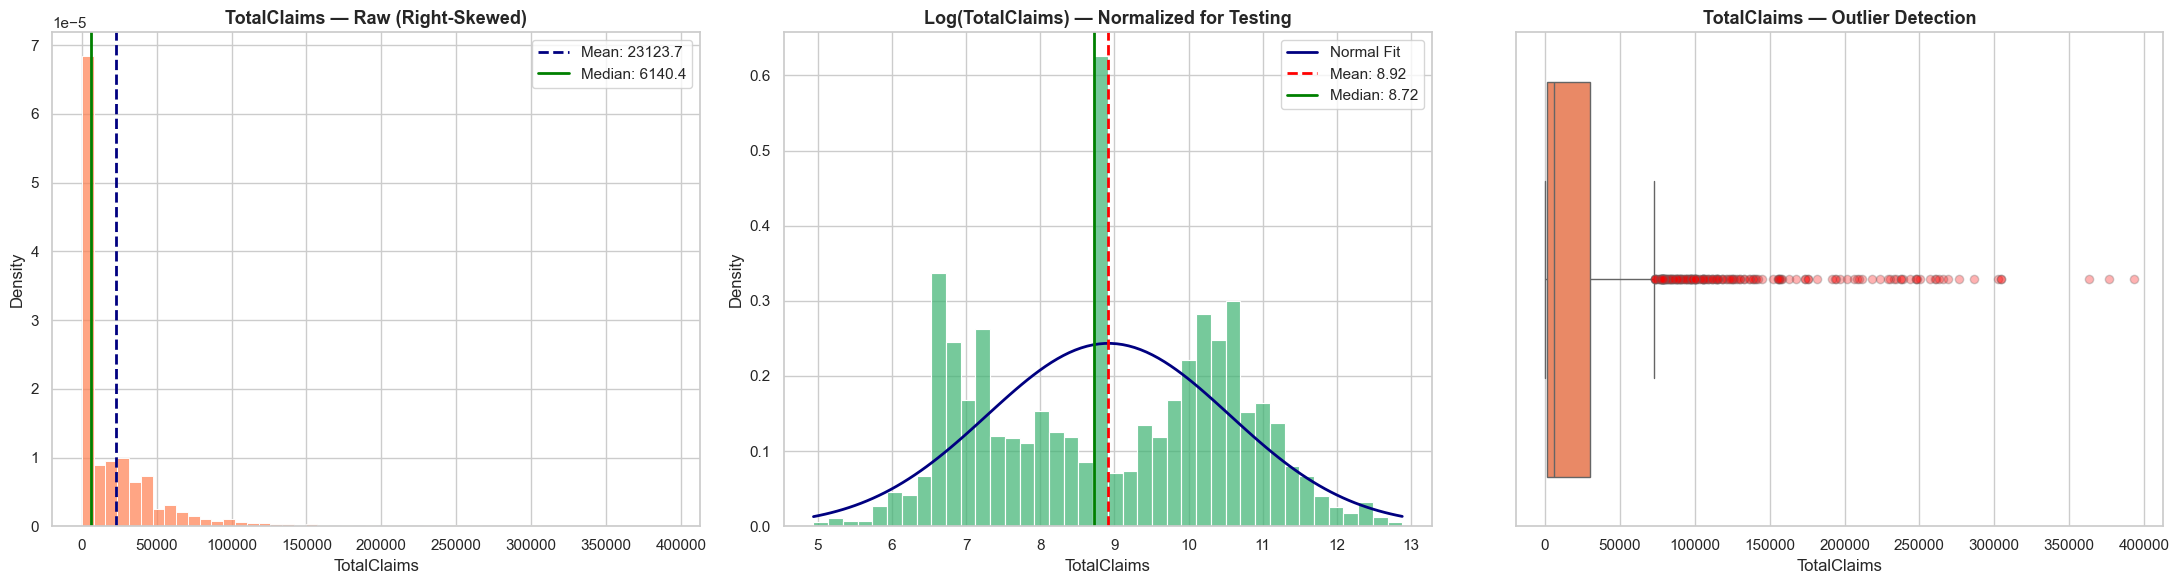

=== Analytical Summary for TotalClaims ===
Mean:     23123.66  ← Pulled RIGHT (Slide 6)
Median:   6140.35  ← More representative of "Typical" risk
Skewness: 3.895  (High Skew)
Outliers: 183 events detected above 73286.75 (IQR Method)
Max Risk: 393092.11 (Highest single value)

ADVICE: Use Log-transformed data for T-tests/ANOVA to satisfy Normality assumptions.


In [ ]:

plot_statistical_distribution(severity_df, column='TotalClaims', title_suffix="- Claim Severity Analysis (Mean vs Median vs Mode)")

#### Margin 

c:\Users\teMelkishi\Desktop\projects\tenx\projects\insurance-risk-analytics\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


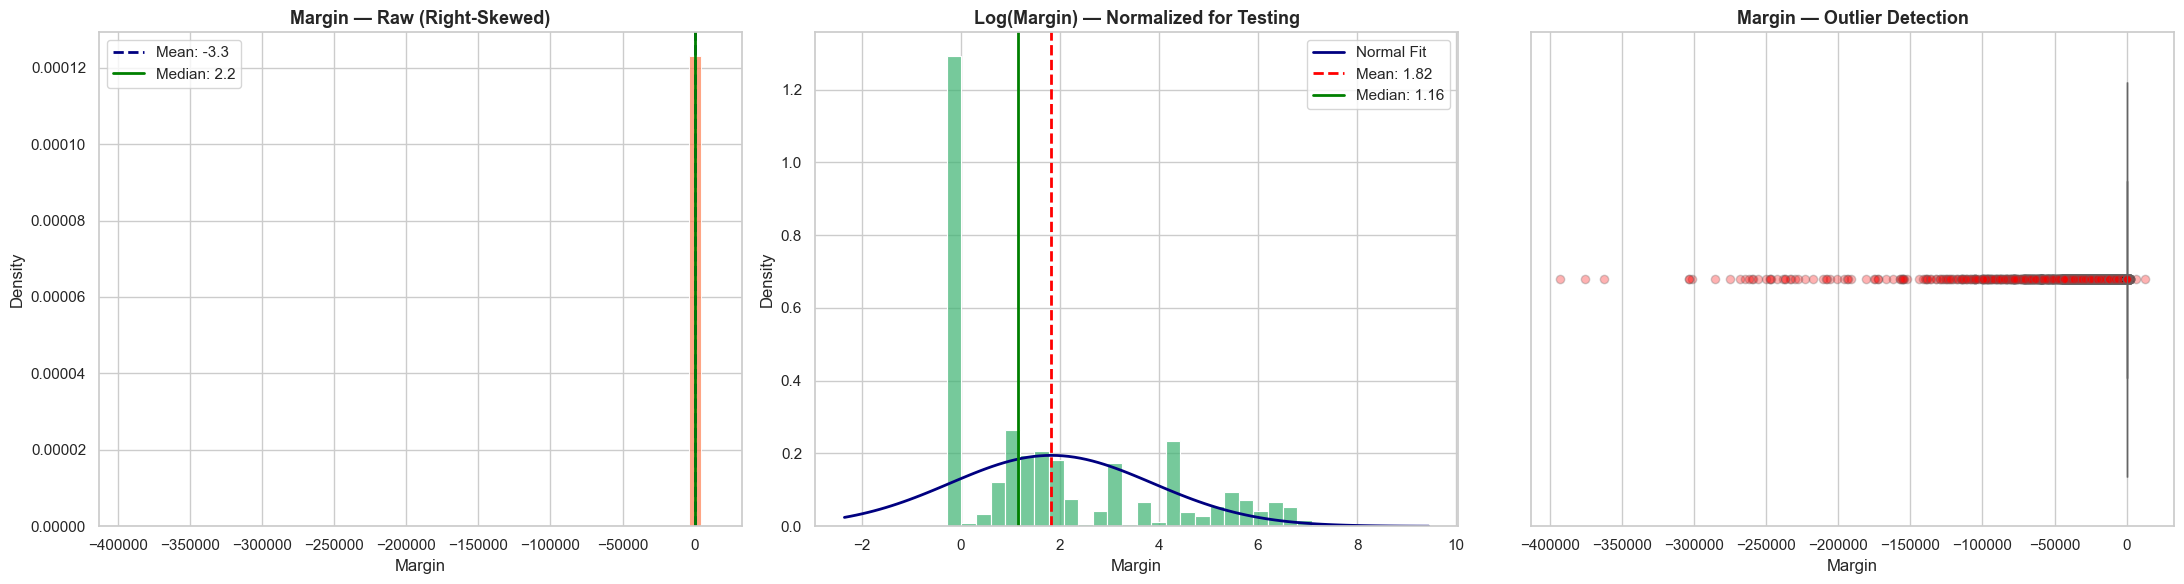

=== Analytical Summary for Margin ===
Mean:     -3.34  ← Pulled LEFT (Slide 6)
Median:   2.18  ← More representative of "Typical" risk
Skewness: -70.563  (High Skew)
Outliers: 204659 events detected above 54.82 (IQR Method)
Max Risk: 12644.25 (Highest single value)

ADVICE: Use Log-transformed data for T-tests/ANOVA to satisfy Normality assumptions.


In [ ]:
plot_statistical_distribution(df, column='Margin', title_suffix='- Profitability Analysis')